<a href="https://colab.research.google.com/github/avaneesh1830/Hand_Gesture_Recognition/blob/main/projectile_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()



Saving projectile_ai_dataset_14000_12.csv to projectile_ai_dataset_14000_12.csv


In [2]:
import pandas as pd

data = pd.read_csv("projectile_ai_dataset_14000_12.csv")  # replace with your filename
print(data.head())



     target_x   target_y  angle_theta  initial_velocity   landing_x  \
0   87.417221  16.585759    62.211568         76.801915  496.491228   
1  191.128575  18.053054    28.344965         73.784794  464.262608   
2  151.758910  68.677634    55.790191         34.129837  110.529895   
3  127.758527  53.824664    58.943923         35.765587  115.369365   
4   48.083355  81.137373    34.158293         78.886284  590.071469   

    landing_y  miss_distance  hit_flag  
0  235.535109     463.983147         0  
1   62.612459     276.744901         0  
2   40.644981      49.856407         0  
3   47.895472      13.734870         0  
4  100.096138     542.319602         0  


✅ Dataset loaded successfully!

⚙️ Model Performance:
Mean Squared Error: 1577.014
R² Score: 0.907

Cross-validation R² scores: [0.90674673 0.9134054  0.90584225 0.90916936 0.9076981 ]
Average CV R²: 0.909


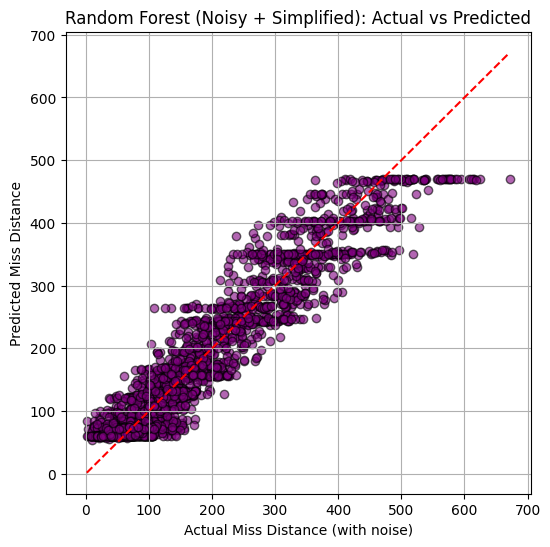

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------
# Load and Slightly Noisify Data
# -----------------------------
data = pd.read_csv("projectile_ai_dataset_14000_12.csv")
print("✅ Dataset loaded successfully!")

# Add small random noise to simulate measurement uncertainty
noise_factor = 0.05
data['miss_distance_noisy'] = data['miss_distance'] * (1 + np.random.randn(len(data)) * noise_factor)

# -----------------------------
# Choose Realistic Input Features
# -----------------------------
X = data[['target_x', 'target_y', 'angle_theta', 'initial_velocity']]
y = data['miss_distance_noisy']

# -----------------------------
# Scale & Split
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# -----------------------------
# Simpler, Less Deep Model
# -----------------------------
model = RandomForestRegressor(
    n_estimators=80,        # fewer trees = less overfit
    max_depth=5,            # limit complexity
    min_samples_leaf=10,    # require more samples per leaf
    random_state=42
)
model.fit(X_train, y_train)

# -----------------------------
# Evaluate
# -----------------------------
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n⚙️ Model Performance:")
print(f"Mean Squared Error: {mse:.3f}")
print(f"R² Score: {r2:.3f}")

cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='r2')
print(f"\nCross-validation R² scores: {cv_scores}")
print(f"Average CV R²: {cv_scores.mean():.3f}")

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='purple', edgecolors='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Miss Distance (with noise)")
plt.ylabel("Predicted Miss Distance")
plt.title("Random Forest (Noisy + Simplified): Actual vs Predicted")
plt.grid(True)
plt.show()

RuntimeError: x must be a sequence

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


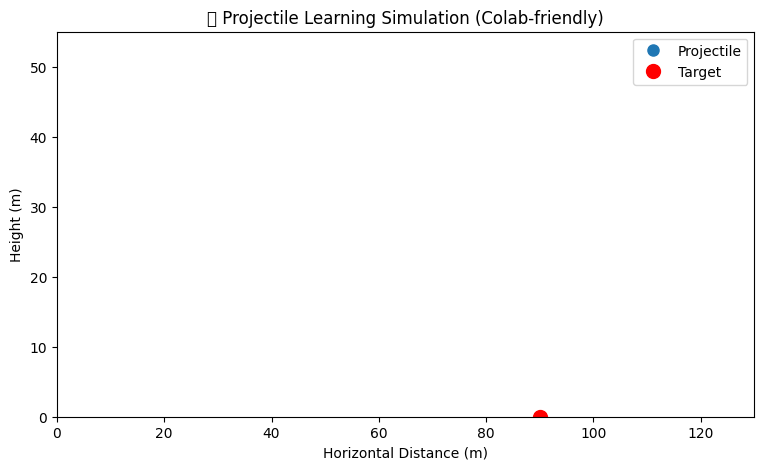

In [4]:
# Colab-ready projectile learning animation (robust)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# --------------------------
# Parameters
# --------------------------
g = 9.8
target_x = 90.0           # target horizontal distance (meters)
target_y = 0.0
initial_learning = 0.15   # start accuracy (0..1)
shots = 10                # number of shots
steps_per_shot = 120      # frames per shot
v_default = 45.0          # projectile speed (m/s)
max_range = v_default**2 / g  # theoretical max range at 45deg

# --------------------------
# Helper: compute trajectory
# --------------------------
def get_trajectory(angle_deg, velocity, npoints=100):
    angle = np.radians(angle_deg)
    # time of flight
    t_flight = 2 * velocity * np.sin(angle) / g
    if t_flight <= 0 or not np.isfinite(t_flight):
        return np.array([0.0]), np.array([0.0])
    t = np.linspace(0, t_flight, npoints)
    x = velocity * np.cos(angle) * t
    y = velocity * np.sin(angle) * t - 0.5 * g * t**2
    y = np.maximum(0, y)  # don't go below ground in plot
    return x, y

# --------------------------
# Pre-generate shot data (simulate "learning")
# --------------------------
shots_data = []
for i in range(shots):
    acc = min(0.999, initial_learning + i * 0.07)  # learning accuracy grows
    # predicted target is imperfect; error shrinks as acc increases
    predicted_target = target_x + np.random.uniform(-30, 30) * (1 - acc)
    # choose a safe angle. Prefer 45°, but if predicted target > max_range, lower angle won't help,
    # so clamp predicted target to reachable range to avoid math issues
    predicted_target_clamped = np.clip(predicted_target, 1e-3, max_range * 0.99)
    # range equation for 45deg approx -> we just use 45deg for consistent arcs
    angle = 45.0
    velocity = v_default
    x, y = get_trajectory(angle, velocity, npoints=steps_per_shot)
    # If predicted_target is left-shifted, we will visualize horizontal shift by translating x
    # compute horizontal offset between ideal landing point at 45deg and predicted_target_clamped
    # ideal landing distance at angle and v:
    ideal_range = velocity**2 * np.sin(2 * np.radians(angle)) / g
    horizontal_shift = predicted_target_clamped - ideal_range
    # shift x by horizontal_shift to place predicted landing point accordingly
    x_shifted = x + horizontal_shift
    miss_distance = abs(predicted_target - target_x)
    shots_data.append({
        "x": x_shifted,
        "y": y,
        "miss": miss_distance,
        "num": i + 1,
        "acc": acc,
        "predicted_target": predicted_target
    })

# --------------------------
# Setup Matplotlib figure
# --------------------------
fig, ax = plt.subplots(figsize=(9,5))
ax.set_xlim(0, max(120, target_x + 40))
ax.set_ylim(0, 55)
ax.set_xlabel("Horizontal Distance (m)")
ax.set_ylabel("Height (m)")
ax.set_title("🎯 Projectile Learning Simulation (Colab-friendly)")

# Elements to animate
proj_dot, = ax.plot([], [], 'o', markersize=8, label="Projectile")
trail_line, = ax.plot([], [], '-', linewidth=1, alpha=0.6)
target_marker, = ax.plot(target_x, target_y, 'ro', markersize=10, label="Target")
info_text = ax.text(0.02, 0.95, "", transform=ax.transAxes, va='top')

ax.legend(loc='upper right')

# --------------------------
# Animation function
# --------------------------
total_frames = shots * steps_per_shot

def init():
    proj_dot.set_data([], [])
    trail_line.set_data([], [])
    info_text.set_text("")
    return proj_dot, trail_line, info_text

def update(frame):
    shot_idx = frame // steps_per_shot
    step = frame % steps_per_shot
    if shot_idx >= len(shots_data):
        return proj_dot, trail_line, info_text

    s = shots_data[shot_idx]
    x = s['x']
    y = s['y']
    # show trail up to current step
    trail_line.set_data(x[:step+1], y[:step+1])
    proj_dot.set_data(x[step], y[step])
    info_text.set_text(
        f"Try #{s['num']}   Miss: {s['miss']:.2f} m   Accuracy: {s['acc']*100:.0f}%\n"
        f"Predicted target: {s['predicted_target']:.1f} m"
    )
    # update title per shot
    ax.set_title(f"🎯 Projectile Learning — Shot {s['num']}/{shots}")
    return proj_dot, trail_line, info_text

# Create animation (blit=False for notebook stability)
ani = FuncAnimation(fig, update, frames=total_frames, init_func=init,
                    interval=30, blit=False, repeat=False)

# Display inline in Colab
HTML(ani.to_jshtml())


In [ ]:
# ✅ Projectile Learning Animation — Colab-safe version
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# --------------------------
# Parameters
# --------------------------
g = 9.8
target_x = 90.0
target_y = 0.0
initial_learning = 0.15
shots = 10
steps_per_shot = 120
v_default = 45.0
max_range = v_default**2 / g

# --------------------------
# Helper: compute trajectory
# --------------------------
def get_trajectory(angle_deg, velocity, npoints=100):
    angle = np.radians(angle_deg)
    t_flight = 2 * velocity * np.sin(angle) / g
    t = np.linspace(0, t_flight, npoints)
    x = velocity * np.cos(angle) * t
    y = velocity * np.sin(angle) * t - 0.5 * g * t**2
    y = np.maximum(0, y)
    return x, y

# --------------------------
# Simulate “learning” shots
# --------------------------
shots_data = []
for i in range(shots):
    acc = min(0.999, initial_learning + i * 0.07)
    predicted_target = target_x + np.random.uniform(-30, 30) * (1 - acc)
    predicted_target = np.clip(predicted_target, 5, max_range * 0.95)

    x, y = get_trajectory(45, v_default, npoints=steps_per_shot)
    ideal_range = v_default**2 * np.sin(2 * np.radians(45)) / g
    horizontal_shift = predicted_target - ideal_range
    x_shifted = x + horizontal_shift
    miss = abs(predicted_target - target_x)

    shots_data.append({
        "x": x_shifted,
        "y": y,
        "miss": miss,
        "num": i + 1,
        "acc": acc,
        "pred": predicted_target
    })

# --------------------------
# Setup figure
# --------------------------
fig, ax = plt.subplots(figsize=(9,5))
ax.set_xlim(0, max(120, target_x + 40))
ax.set_ylim(0, 55)
ax.set_xlabel("Horizontal Distance (m)")
ax.set_ylabel("Height (m)")
ax.set_title("Projectile Learning Simulation (AI improving over time)")

proj_dot, = ax.plot([], [], 'o', color='orange', markersize=8, label="Projectile")
trail_line, = ax.plot([], [], '-', linewidth=1, alpha=0.6)
target_marker, = ax.plot(target_x, target_y, 'ro', markersize=10, label="Target")
info_text = ax.text(0.02, 0.95, "", transform=ax.transAxes, va='top')

ax.legend(loc='upper right')

# --------------------------
# Animation
# --------------------------
total_frames = shots * steps_per_shot

def init():
    proj_dot.set_data([], [])
    trail_line.set_data([], [])
    info_text.set_text("")
    return proj_dot, trail_line, info_text

def update(frame):
    shot_idx = frame // steps_per_shot
    step = frame % steps_per_shot
    if shot_idx >= len(shots_data):
        return proj_dot, trail_line, info_text

    s = shots_data[shot_idx]
    x, y = s["x"], s["y"]

    # Draw up to current point
    trail_line.set_data(x[:step+1], y[:step+1])
    proj_dot.set_data([x[step]], [y[step]])  # ✅ FIXED: wrap in list
    info_text.set_text(
        f"Try #{s['num']}  |  Miss: {s['miss']:.2f} m  |  Accuracy: {s['acc']*100:.0f}%"
    )
    ax.set_title(f"Projectile Learning — Shot {s['num']}/{shots}")
    return proj_dot, trail_line, info_text

ani = FuncAnimation(fig, update, frames=total_frames, init_func=init,
                    interval=30, blit=False, repeat=False)

# Display animation inline
HTML(ani.to_jshtml())


In [ ]:
# ✅ Projectile Learning Animation — Google Colab Safe Version
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib as mpl

# Allow large animations to embed inline (fix for Colab limit)
mpl.rcParams['animation.embed_limit'] = 200  # MB

# --------------------------
# Parameters
# --------------------------
g = 9.8
target_x = 90.0
target_y = 0.0
initial_learning = 0.15
shots = 10
steps_per_shot = 120
v_default = 45.0
max_range = v_default**2 / g

# --------------------------
# Helper: compute trajectory
# --------------------------
def get_trajectory(angle_deg, velocity, npoints=100):
    angle = np.radians(angle_deg)
    t_flight = 2 * velocity * np.sin(angle) / g
    t = np.linspace(0, t_flight, npoints)
    x = velocity * np.cos(angle) * t
    y = velocity * np.sin(angle) * t - 0.5 * g * t**2
    y = np.maximum(0, y)
    return x, y

# --------------------------
# Simulate “learning” shots
# --------------------------
shots_data = []
for i in range(shots):
    acc = min(0.999, initial_learning + i * 0.07)
    predicted_target = target_x + np.random.uniform(-30, 30) * (1 - acc)
    predicted_target = np.clip(predicted_target, 5, max_range * 0.95)

    x, y = get_trajectory(45, v_default, npoints=steps_per_shot)
    ideal_range = v_default**2 * np.sin(2 * np.radians(45)) / g
    horizontal_shift = predicted_target - ideal_range
    x_shifted = x + horizontal_shift
    miss = abs(predicted_target - target_x)

    shots_data.append({
        "x": x_shifted,
        "y": y,
        "miss": miss,
        "num": i + 1,
        "acc": acc,
        "pred": predicted_target
    })

# --------------------------
# Setup figure
# --------------------------
fig, ax = plt.subplots(figsize=(9,5))
ax.set_xlim(0, max(120, target_x + 40))
ax.set_ylim(0, 55)
ax.set_xlabel("Horizontal Distance (m)")
ax.set_ylabel("Height (m)")
ax.set_title("Projectile Learning Simulation (AI improving over time)")

proj_dot, = ax.plot([], [], 'o', color='orange', markersize=8, label="Projectile")
trail_line, = ax.plot([], [], '-', linewidth=1, alpha=0.6)
target_marker, = ax.plot(target_x, target_y, 'ro', markersize=10, label="Target")
info_text = ax.text(0.02, 0.95, "", transform=ax.transAxes, va='top')

ax.legend(loc='upper right')

# --------------------------
# Animation
# --------------------------
total_frames = shots * steps_per_shot

def init():
    proj_dot.set_data([], [])
    trail_line.set_data([], [])
    info_text.set_text("")
    return proj_dot, trail_line, info_text

def update(frame):
    shot_idx = frame // steps_per_shot
    step = frame % steps_per_shot
    if shot_idx >= len(shots_data):
        return proj_dot, trail_line, info_text

    s = shots_data[shot_idx]
    x, y = s["x"], s["y"]

    # Draw up to current point
    trail_line.set_data(x[:step+1], y[:step+1])
    proj_dot.set_data([x[step]], [y[step]])  # ✅ FIXED
    info_text.set_text(
        f"Try #{s['num']}  |  Miss: {s['miss']:.2f} m  |  Accuracy: {s['acc']*100:.0f}%"
    )
    ax.set_title(f"Projectile Learning — Shot {s['num']}/{shots}")
    return proj_dot, trail_line, info_text

ani = FuncAnimation(fig, update, frames=total_frames, init_func=init,
                    interval=30, blit=False, repeat=False)

# Display animation inline
HTML(ani.to_jshtml())
